# 🎯 Forex XGBoost Trading Filter — Complete Playbook

**Pipeline:** Data → Regime Detection → Features → Labels → Walk-Forward Training → Live Inference → Backtest → Risk Management

**New:** Dynamic direction detection — no more hardcoded long/short. The system adapts to market regime.

**Prerequisites:** `pip install pandas numpy xgboost scikit-learn joblib matplotlib seaborn oandapyV20`

## 🔧 Environment Setup & Package Check

In [1]:
import importlib, subprocess, sys

required = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'xgboost': 'xgboost>=2.0',
    'joblib': 'joblib',
    'oandapyV20': 'oandapyV20'
}

missing = []
for mod, pkg in required.items():
    try:
        importlib.import_module(mod)
        print(f'  ✅ {mod}')
    except ImportError:
        print(f'  ❌ {mod} — run: pip install {pkg}')
        missing.append(pkg)

if missing:
    print(f'\n⚠️ Missing packages: {missing}')
    print('Install with: pip install ' + ' '.join(missing))
else:
    print('\n✅ All packages available')

import xgboost as xgb
print(f'\nXGBoost version: {xgb.__version__}')
print(f'XGBClassifier available: {hasattr(xgb, "XGBClassifier")}')

import os
if os.path.exists('xgboost.py') or os.path.exists('xgboost.pyc'):
    print('\n🚨 WARNING: Found xgboost.py in working directory — rename it!')

  ✅ pandas
  ✅ numpy
  ✅ matplotlib
  ✅ seaborn
  ✅ sklearn
  ✅ xgboost
  ✅ joblib
  ✅ oandapyV20

✅ All packages available

XGBoost version: 3.3.0
XGBClassifier available: True


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
import warnings
from typing import Dict, List, Tuple, Optional
from sklearn.metrics import accuracy_score, precision_score, f1_score
from datetime import datetime
from packaging import version

import oandapyV20
from oandapyV20.endpoints.instruments import InstrumentsCandles

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ All imports loaded')

✅ All imports loaded


## ⚙️ Configuration

Import from your `config.py` or set values directly. **DIRECTION** can be `'auto'`, `'long'`, or `'short'`. When `'auto'`, the system detects market regime using EMA cross.

In [3]:
# ═══════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════
import config


def cfg(name, default):
    return getattr(config, name, default)

OANDA_ACCOUNT_ID = cfg("OANDA_ACCOUNT_ID", "")
OANDA_TOKEN = cfg("OANDA_API_TOKEN", "")
GRANULARITY = cfg("ML_TRAIN_GRANULARITY", "")
OANDA_ENV = cfg('OANDA_ENV', 'practice')
INSTRUMENT = cfg("INSTRUMENT", 'EUR_USD')
DIRECTION = cfg("DIRECTION", 'auto')

assert (OANDA_ACCOUNT_ID.strip() and OANDA_TOKEN.strip() and GRANULARITY.strip() and OANDA_ENV.strip() and \
    INSTRUMENT.strip(), DIRECTION.strip()),  "some parmas are empty. Set it in config file."

# Regime detection parameters (used when DIRECTION='auto')
REGIME_FAST_EMA = cfg("REGIME_FAST_EMA", 20)
REGIME_SLOW_EMA = cfg("REGIME_SLOW_EMA", 50)

# Risk Parameters
RISK_MULTIPLE = cfg("RISK_MULTIPLE", 1.0)
REWARD_MULTIPLE = cfg("REWARD_MULTIPLE", 2.0)
MAX_BARS = cfg("MAX_BARS", 20)
ATR_PERIOD = cfg("ATR_PERIOD", 14)

# Model Parameters
TRAIN_WINDOW = cfg("TRAIN_WINDOW", 3000)
TEST_WINDOW = cfg("TEST_WINDOW", 500)
STEP_SIZE = cfg("STEP_SIZE", 500)
THRESHOLD = cfg("THRESHOLD", 0.6)

# Feature Lookbacks
LOOKBACKS = cfg("LOOKBACKS", [5, 10, 20, 50])

print(f"📊 {INSTRUMENT} | {GRANULARITY} | Direction: {DIRECTION}")
print(f"🎯 Risk:{RISK_MULTIPLE}R | Reward:{REWARD_MULTIPLE}R | Threshold:{THRESHOLD}")

📊 EUR_USD | H1 | Direction: auto
🎯 Risk:1.0R | Reward:2.0R | Threshold:0.6


## 🌊 Layer 0: Regime Detection (Dynamic Direction)

When `DIRECTION='auto'`, the system detects whether the market is in an uptrend or downtrend using EMA cross, and only trades in that direction. This avoids fighting the trend.

In [4]:
def detect_direction(df: pd.DataFrame, fast: int = 20, slow: int = 50) -> str:
    """
    Detect market regime direction from price vs EMAs.
    Returns 'long' if uptrend, 'short' if downtrend.
    """
    # Ensure EMAs exist
    if f'ema_{fast}' not in df.columns:
        df[f'ema_{fast}'] = df['close'].ewm(span=fast, adjust=False).mean()
    if f'ema_{slow}' not in df.columns:
        df[f'ema_{slow}'] = df['close'].ewm(span=slow, adjust=False).mean()
    
    latest = df.iloc[-1]
    price = latest['close']
    ema_fast = latest[f'ema_{fast}']
    ema_slow = latest[f'ema_{slow}']
    
    if pd.isna(ema_slow):
        return 'long'  # Default if insufficient data
    
    # Uptrend: price above slow EMA AND fast above slow
    if price > ema_slow and ema_fast > ema_slow:
        return 'long'
    # Downtrend: price below slow EMA AND fast below slow
    elif price < ema_slow and ema_fast < ema_slow:
        return 'short'
    # Transition / chop — default to no trade or use previous
    else:
        # In transition, stick with previous bar's direction if available
        prev = df.iloc[-2]
        prev_fast = prev.get(f'ema_{fast}', np.nan)
        prev_slow = prev.get(f'ema_{slow}', np.nan)
        if not pd.isna(prev_slow):
            if prev_fast > prev_slow:
                return 'long'
            else:
                return 'short'
        return 'long'  # Ultimate fallback

def get_direction_for_bar(df: pd.DataFrame, idx: int, fast: int = 20, slow: int = 50) -> str:
    """Get direction for a specific historical bar (for backtest)."""
    if f'ema_{fast}' not in df.columns:
        df[f'ema_{fast}'] = df['close'].ewm(span=fast, adjust=False).mean()
    if f'ema_{slow}' not in df.columns:
        df[f'ema_{slow}'] = df['close'].ewm(span=slow, adjust=False).mean()
    
    row = df.iloc[idx]
    price = row['close']
    ema_fast = row[f'ema_{fast}']
    ema_slow = row[f'ema_{slow}']
    
    if pd.isna(ema_slow):
        return 'long'
    if price > ema_slow and ema_fast > ema_slow:
        return 'long'
    elif price < ema_slow and ema_fast < ema_slow:
        return 'short'
    else:
        # Use previous bar's regime
        if idx > 0:
            prev = df.iloc[idx-1]
            prev_fast = prev.get(f'ema_{fast}', np.nan)
            prev_slow = prev.get(f'ema_{slow}', np.nan)
            if not pd.isna(prev_slow):
                return 'long' if prev_fast > prev_slow else 'short'
        return 'long'

print('✅ Regime detection functions defined')
print(f"   Fast EMA: {REGIME_FAST_EMA} | Slow EMA: {REGIME_SLOW_EMA}")

✅ Regime detection functions defined
   Fast EMA: 20 | Slow EMA: 30


## 🔧 Layer 1: Feature Engineering

In [5]:
class ForexFeatureEngineer:
    def __init__(self, lookback_periods=None, atr_period=14):
        self.lookbacks = lookback_periods or [5, 10, 20, 50]
        self.atr_period = atr_period
    
    def compute_features(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df[f'atr_{self.atr_period}'] = self._atr(df, self.atr_period)
        for period in self.lookbacks:
            df[f'ema_{period}'] = df['close'].ewm(span=period, adjust=False).mean()
            df[f'sma_{period}'] = df['close'].rolling(window=period).mean()
            df[f'close_dist_ema_{period}'] = (df['close'] - df[f'ema_{period}']) / df[f'ema_{period}']
            df[f'atr_{period}'] = self._atr(df, period)
            df[f'volatility_{period}'] = df['close'].rolling(period).std() / df['close'].rolling(period).mean()
            df[f'momentum_{period}'] = df['close'].pct_change(period)
            df[f'roc_{period}'] = (df['close'] - df['close'].shift(period)) / df['close'].shift(period)
            df[f'hl_position_{period}'] = (df['close'] - df['low'].rolling(period).min()) / (
                df['high'].rolling(period).max() - df['low'].rolling(period).min() + 1e-9)
        df['body_size'] = abs(df['close'] - df['open']) / df['open']
        df['upper_wick'] = (df['high'] - df[['close','open']].max(axis=1)) / df['open']
        df['lower_wick'] = (df[['close','open']].min(axis=1) - df['low']) / df['open']
        df['range'] = (df['high'] - df['low']) / df['low']
        df['bullish'] = (df['close'] > df['open']).astype(int)
        if 'volume' in df.columns and df['volume'].notna().any():
            df['volume_sma_20'] = df['volume'].rolling(20).mean()
            df['volume_ratio'] = df['volume'] / df['volume_sma_20']
            df['volume_momentum'] = df['volume'].pct_change(5)
        df['hour'] = df.index.hour
        df['day_of_week'] = df.index.dayofweek
        df['is_london'] = ((df['hour'] >= 8) & (df['hour'] <= 16)).astype(int)
        df['is_ny'] = ((df['hour'] >= 13) & (df['hour'] <= 21)).astype(int)
        return df
    
    def _atr(self, df, period):
        high_low = df['high'] - df['low']
        high_close = abs(df['high'] - df['close'].shift())
        low_close = abs(df['low'] - df['close'].shift())
        tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
        return tr.rolling(window=period).mean()
    
    def get_feature_columns(self, df):
        exclude = ['open', 'high', 'low', 'close', 'volume', 'target']
        return [c for c in df.columns if c not in exclude]

print('✅ ForexFeatureEngineer defined')

✅ ForexFeatureEngineer defined


## 🏷️ Layer 2: Label Generation

Target: Will price move 2R profit before hitting 1R loss within N bars? Labels are generated for the specified direction.

In [6]:
class LabelGenerator:
    def __init__(self, risk_multiple=1.0, reward_multiple=2.0, max_bars=20, atr_period=14):
        self.risk_multiple = risk_multiple
        self.reward_multiple = reward_multiple
        self.max_bars = max_bars
        self.atr_period = atr_period
    
    def generate_labels(self, df, direction='long'):
        atr = self._atr(df, self.atr_period)
        labels = pd.Series(index=df.index, dtype=float)
        labels[:] = -1
        for i in range(len(df) - self.max_bars):
            if pd.isna(atr.iloc[i]): continue
            entry = df['close'].iloc[i]
            atr_val = atr.iloc[i]
            if direction == 'long':
                sl = entry - atr_val * self.risk_multiple
                tp = entry + atr_val * self.reward_multiple
            else:
                sl = entry + atr_val * self.risk_multiple
                tp = entry - atr_val * self.reward_multiple
            future = df.iloc[i+1:i+1+self.max_bars]
            if direction == 'long':
                stop_hit = (future['low'] <= sl).any()
                target_hit = (future['high'] >= tp).any()
            else:
                stop_hit = (future['high'] >= sl).any()
                target_hit = (future['low'] <= tp).any()
            if target_hit and not stop_hit: labels.iloc[i] = 1
            elif stop_hit and not target_hit: labels.iloc[i] = 0
            elif stop_hit and target_hit: labels.iloc[i] = self._first_hit(future, sl, tp, direction)
            else: labels.iloc[i] = 0
        return labels
    
    def _first_hit(self, future, stop, target, direction):
        for _, bar in future.iterrows():
            if direction == 'long':
                if bar['low'] <= stop: return 0
                if bar['high'] >= target: return 1
            else:
                if bar['high'] >= stop: return 0
                if bar['low'] <= target: return 1
        return 0
    
    def _atr(self, df, period):
        high_low = df['high'] - df['low']
        high_close = abs(df['high'] - df['close'].shift())
        low_close = abs(df['low'] - df['close'].shift())
        tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
        return tr.rolling(window=period).mean()

print('✅ LabelGenerator defined')

✅ LabelGenerator defined


## 📥 Layer 3: Data Ingestion

Fetch from OANDA API or use synthetic data for demonstration.

In [7]:
def fetch_oanda_data(instrument, granularity, count=5000, token=None):
    if token is None or token == 'YOUR_ACCESS_TOKEN':
        print('⚠️ Using synthetic demo data. Replace OANDA_TOKEN for live data.')
        np.random.seed(42)
        n = count
        dates = pd.date_range(end=datetime.now(), periods=n, freq='H')
        returns = np.random.normal(0.0001, 0.001, n)
        close = 1.0850 * np.exp(np.cumsum(returns))
        high = close * (1 + abs(np.random.normal(0, 0.001, n)))
        low = close * (1 - abs(np.random.normal(0, 0.001, n)))
        open_p = close * (1 + np.random.normal(0, 0.0005, n))
        volume = np.random.randint(1000, 10000, n)
        return pd.DataFrame({'open': open_p, 'high': high, 'low': low, 'close': close, 'volume': volume}, index=dates)
    client = oandapyV20.API(access_token=token, environment=OANDA_ENV)
    params = {'count': count, 'granularity': granularity, 'price': 'M'}
    r = InstrumentsCandles(instrument=instrument, params=params)
    client.request(r)
    data = []
    for c in r.response['candles']:
        if not c['complete']: continue
        data.append({'time': pd.to_datetime(c['time']), 'open': float(c['mid']['o']),
                     'high': float(c['mid']['h']), 'low': float(c['mid']['l']),
                     'close': float(c['mid']['c']), 'volume': int(c['volume'])})
    return pd.DataFrame(data).set_index('time')

df_raw = fetch_oanda_data(INSTRUMENT, GRANULARITY, count=5000, token=OANDA_TOKEN)
print(f"📈 Loaded {len(df_raw)} bars | {df_raw.index[0]} → {df_raw.index[-1]}")
df_raw.tail()

📈 Loaded 4999 bars | 2025-10-08 01:00:00+00:00 → 2026-07-29 07:00:00+00:00


,open,high,low,close,volume
time,,,,,
2026-07-29 03:00:00+00:00,1.13948,1.14008,1.13945,1.13970,2153
2026-07-29 04:00:00+00:00,1.13970,1.14036,1.13963,1.14011,2758
2026-07-29 05:00:00+00:00,1.14013,1.14030,1.13976,1.13983,2478
2026-07-29 06:00:00+00:00,1.13982,1.14008,1.13900,1.13921,4122
2026-07-29 07:00:00+00:00,1.13920,1.14010,1.13903,1.13979,4141


## 🧪 Layer 3b: Prepare Data & Detect Regime

Compute features and determine training direction. If `DIRECTION='auto'`, we detect the current regime from the latest data.

In [8]:
fe = ForexFeatureEngineer(lookback_periods=LOOKBACKS, atr_period=ATR_PERIOD)
df = fe.compute_features(df_raw)

# Detect direction for training
if DIRECTION == 'auto':
    TRAIN_DIRECTION = detect_direction(df, fast=REGIME_FAST_EMA, slow=REGIME_SLOW_EMA)
    print(f"🌊 Auto-detected regime: {TRAIN_DIRECTION.upper()}")
else:
    TRAIN_DIRECTION = DIRECTION
    print(f"📌 Fixed direction: {TRAIN_DIRECTION.upper()}")

# Generate labels for detected direction
lg = LabelGenerator(risk_multiple=RISK_MULTIPLE, reward_multiple=REWARD_MULTIPLE,
                    max_bars=MAX_BARS, atr_period=ATR_PERIOD)
df['target'] = lg.generate_labels(df, direction=TRAIN_DIRECTION)
feature_cols = fe.get_feature_columns(df)
df_clean = df.dropna(subset=feature_cols + ['target'])
df_clean = df_clean[df_clean['target'].isin([0, 1])]

print(f"✅ Clean: {len(df_clean)} samples | {len(feature_cols)} features")
print(f"🎯 Distribution ({TRAIN_DIRECTION}):\n{df_clean['target'].value_counts(normalize=True)}")
print(f"📊 ATR columns: {[c for c in df_clean.columns if 'atr_' in c]}")
df_clean[['close','target'] + feature_cols[:5]].tail()

🌊 Auto-detected regime: LONG
✅ Clean: 4929 samples | 46 features
🎯 Distribution (long):
target
0.0    0.707446
1.0    0.292554
Name: proportion, dtype: float64
📊 ATR columns: ['atr_14', 'atr_5', 'atr_10', 'atr_20', 'atr_50']


,close,target,atr_14,ema_5,sma_5,close_dist_ema_5,atr_5
time,,,,,,,
2026-07-28 07:00:00+00:00,1.13649,0.0,0.000648,1.136809,1.136856,-0.000280,0.000766
2026-07-28 08:00:00+00:00,1.13726,0.0,0.000660,1.136959,1.136816,0.000265,0.000798
2026-07-28 09:00:00+00:00,1.13564,1.0,0.000740,1.136519,1.136570,-0.000774,0.001010
2026-07-28 10:00:00+00:00,1.13607,1.0,0.000774,1.136370,1.136466,-0.000264,0.001068
2026-07-28 11:00:00+00:00,1.13653,1.0,0.000812,1.136423,1.136398,0.000094,0.001130


## 📊 Layer 4: Exploratory Visualization

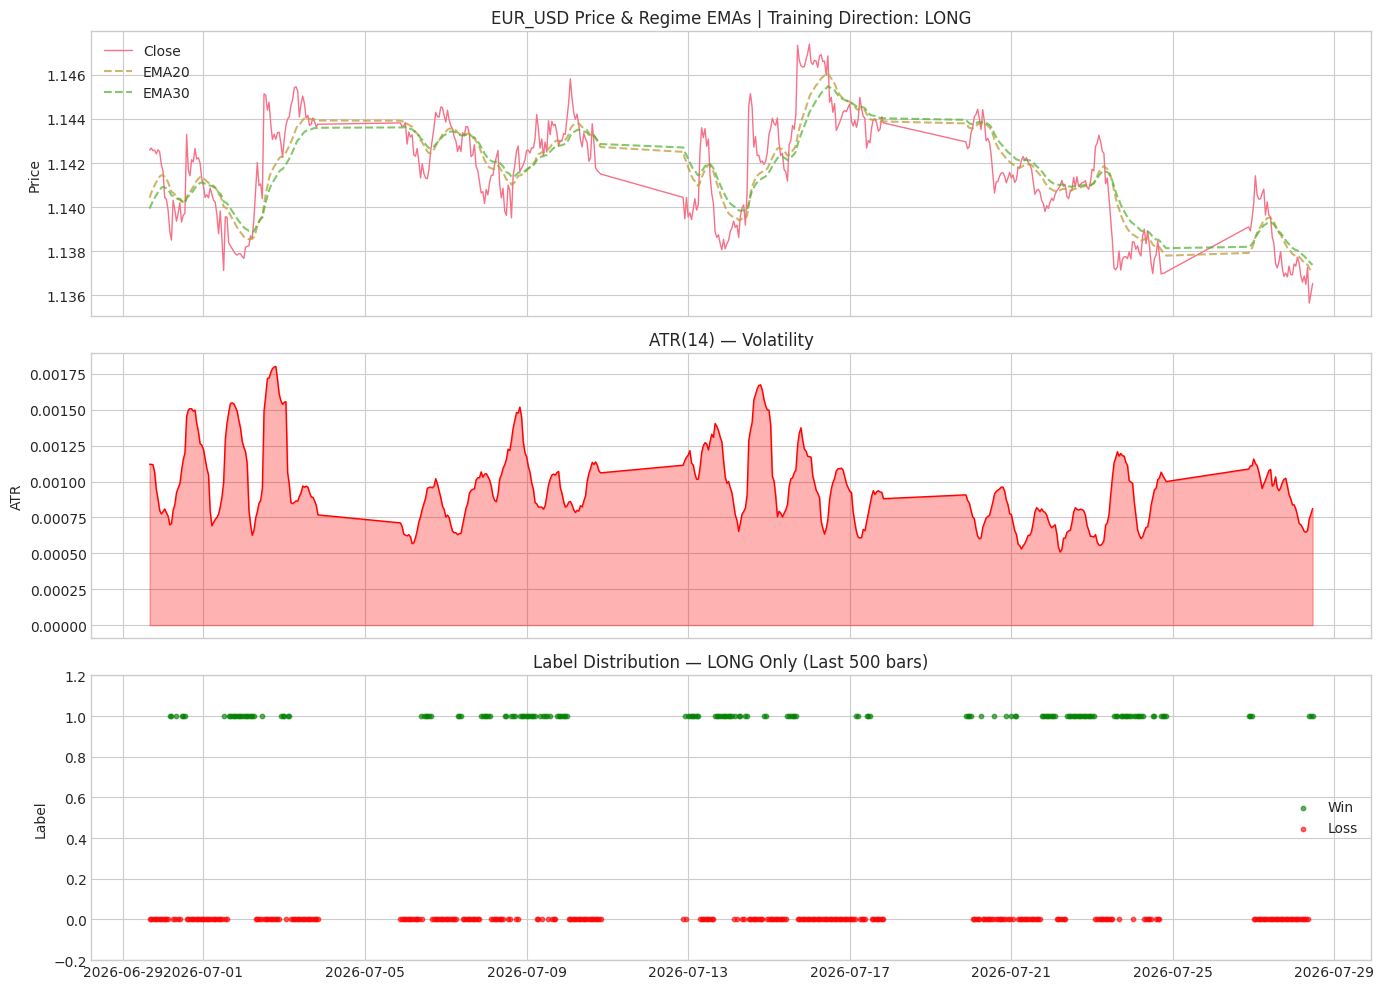

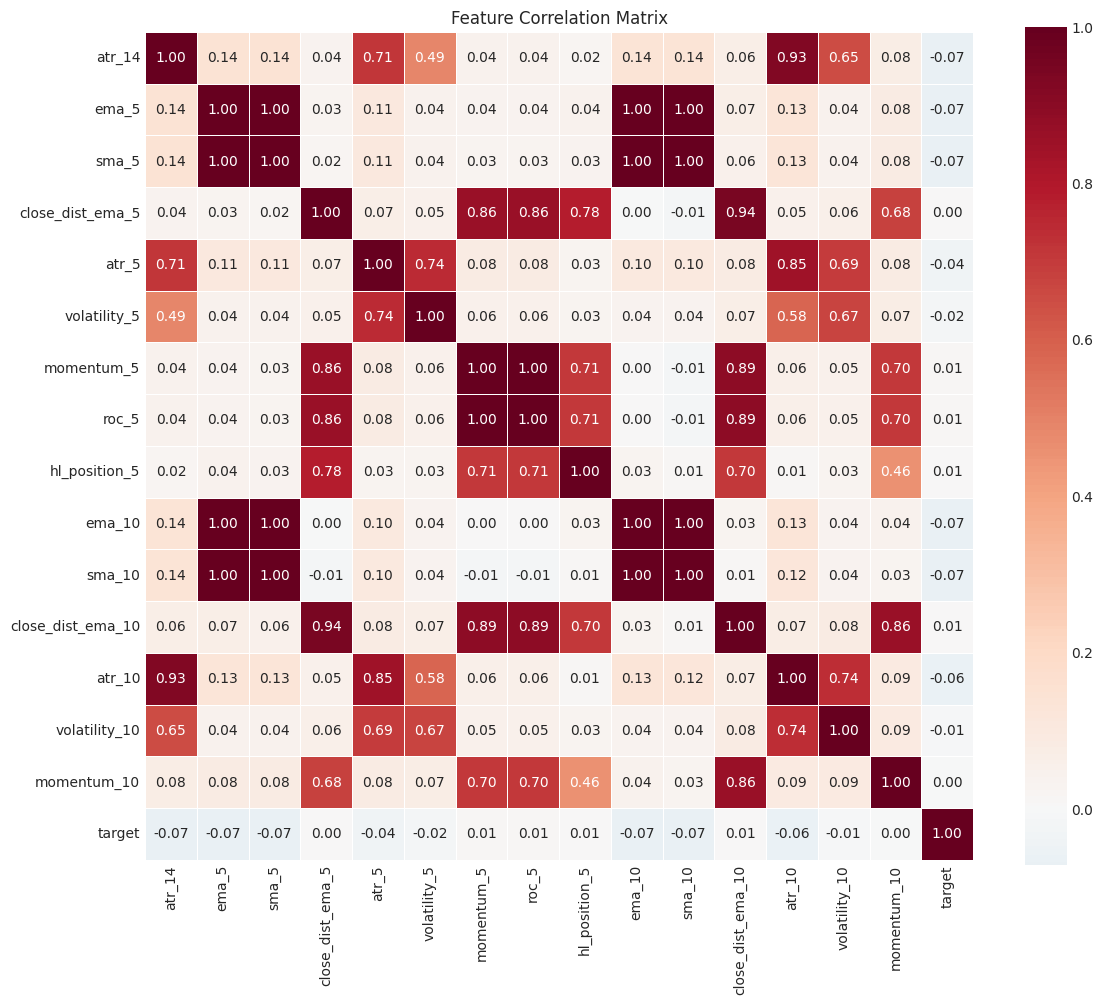

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
ax1 = axes[0]
ax1.plot(df_clean.index[-500:], df_clean['close'].iloc[-500:], label='Close', linewidth=1)
for period in [REGIME_FAST_EMA, REGIME_SLOW_EMA]:
    ax1.plot(df_clean.index[-500:], df_clean[f'ema_{period}'].iloc[-500:], label=f'EMA{period}', alpha=0.7, linestyle='--')
ax1.set_title(f'{INSTRUMENT} Price & Regime EMAs | Training Direction: {TRAIN_DIRECTION.upper()}')
ax1.legend(loc='upper left')
ax1.set_ylabel('Price')

ax2 = axes[1]
atr_col = f'atr_{ATR_PERIOD}'
ax2.fill_between(df_clean.index[-500:], df_clean[atr_col].iloc[-500:], alpha=0.3, color='red')
ax2.plot(df_clean.index[-500:], df_clean[atr_col].iloc[-500:], color='red', linewidth=1)
ax2.set_title(f'ATR({ATR_PERIOD}) — Volatility')
ax2.set_ylabel('ATR')

ax3 = axes[2]
labels_s = df_clean['target'].iloc[-500:]
wins = labels_s[labels_s == 1].index
losses = labels_s[labels_s == 0].index
ax3.scatter(wins, [1]*len(wins), color='green', alpha=0.6, s=10, label='Win')
ax3.scatter(losses, [0]*len(losses), color='red', alpha=0.6, s=10, label='Loss')
ax3.set_title(f'Label Distribution — {TRAIN_DIRECTION.upper()} Only (Last 500 bars)')
ax3.set_ylabel('Label')
ax3.set_ylim(-0.2, 1.2)
ax3.legend()
plt.tight_layout()
plt.show()

top_features = feature_cols[:15]
corr = df_clean[top_features + ['target']].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 🤖 Layer 5: Walk-Forward XGBoost Training

Train on rolling windows for the detected/fixed direction.

In [10]:
class WalkForwardXGB:
    def __init__(self, train_window=3000, test_window=500, step_size=500, threshold=0.6):
        self.train_window = train_window
        self.test_window = test_window
        self.step_size = step_size
        self.threshold = threshold
        self.model = None
        self.feature_cols = None
        self.results = []
        self.models = []
    
    def _fit_model(self, model, X_train, y_train, X_test, y_test):
        try:
            model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
                      early_stopping_rounds=30, verbose=False)
        except TypeError as e:
            if 'early_stopping_rounds' in str(e):
                print('    ⚠️ Old XGBoost detected, fitting without early stopping')
                model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
            else:
                raise
        return model
    
    def train(self, df, feature_cols):
        self.feature_cols = feature_cols
        df = df.reset_index(drop=True)
        n = len(df)
        best_trade_acc = 0
        for start in range(0, n - self.train_window - self.test_window, self.step_size):
            train_s, train_e = start, start + self.train_window
            test_s, test_e = train_e, train_e + self.test_window
            X_train = df.iloc[train_s:train_e][feature_cols]
            y_train = df.iloc[train_s:train_e]['target']
            X_test = df.iloc[test_s:test_e][feature_cols]
            y_test = df.iloc[test_s:test_e]['target']
            pos = (y_train == 1).sum()
            neg = (y_train == 0).sum()
            scale_weight = neg / pos if pos > 0 else 1
            model = xgb.XGBClassifier(
                n_estimators=300, max_depth=5, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=scale_weight, eval_metric='logloss',
                random_state=42, n_jobs=-1)
            model = self._fit_model(model, X_train, y_train, X_test, y_test)
            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1]
            trades = y_proba >= self.threshold
            trade_acc = (y_test[trades] == 1).mean() if trades.sum() > 0 else 0
            trade_prec = precision_score(y_test[trades], y_pred[trades], zero_division=0) if trades.sum() > 0 else 0
            self.results.append({
                'fold': len(self.results), 'train_start': train_s, 'test_start': test_s,
                'accuracy': accuracy_score(y_test, y_pred),
                'precision': precision_score(y_test, y_pred, zero_division=0),
                'f1': f1_score(y_test, y_pred, zero_division=0),
                'trade_accuracy': trade_acc, 'trade_precision': trade_prec,
                'trade_rate': trades.mean(), 'n_trades': int(trades.sum()),
                'avg_proba': y_proba.mean(), 'best_iter': getattr(model, 'best_iteration', 300)})
            self.models.append(model)
            if trade_acc > best_trade_acc:
                best_trade_acc = trade_acc
                self.model = model
                joblib.dump(model, f'best_xgb_model_{TRAIN_DIRECTION}.pkl')
        return pd.DataFrame(self.results)
    
    def feature_importance(self):
        if self.model is None:
            raise ValueError('No model trained yet. Run .train() first.')
        imp = pd.DataFrame({'feature': self.feature_cols, 'importance': self.model.feature_importances_})
        return imp.sort_values('importance', ascending=False)
    
    def predict(self, X):
        if self.model is None:
            raise ValueError('No model trained yet. Run .train() first.')
        proba = self.model.predict_proba(X)[:, 1][0]
        return (1 if proba >= self.threshold else 0), float(proba)

wfx = WalkForwardXGB(train_window=TRAIN_WINDOW, test_window=TEST_WINDOW,
                     step_size=STEP_SIZE, threshold=THRESHOLD)
print(f'🚀 Starting walk-forward training for {TRAIN_DIRECTION.upper()}...')
results_df = wfx.train(df_clean, feature_cols)
print(f"✅ {len(results_df)} folds complete")
print(f"✅ Model saved: best_xgb_model_{TRAIN_DIRECTION}.pkl")
results_df

🚀 Starting walk-forward training for LONG...
    ⚠️ Old XGBoost detected, fitting without early stopping
    ⚠️ Old XGBoost detected, fitting without early stopping
    ⚠️ Old XGBoost detected, fitting without early stopping
✅ 3 folds complete
✅ Model saved: best_xgb_model_long.pkl


,fold,train_start,test_start,accuracy,precision,f1,trade_accuracy,trade_precision,trade_rate,n_trades,avg_proba,best_iter
0,0,0,3000,0.546,0.363636,0.219931,0.358491,0.358491,0.106,53,0.316999,300
1,1,500,3500,0.620,0.315217,0.379085,0.350427,0.350427,0.234,117,0.420148,300
2,2,1000,4000,0.454,0.226087,0.275862,0.251462,0.251462,0.342,171,0.485685,300


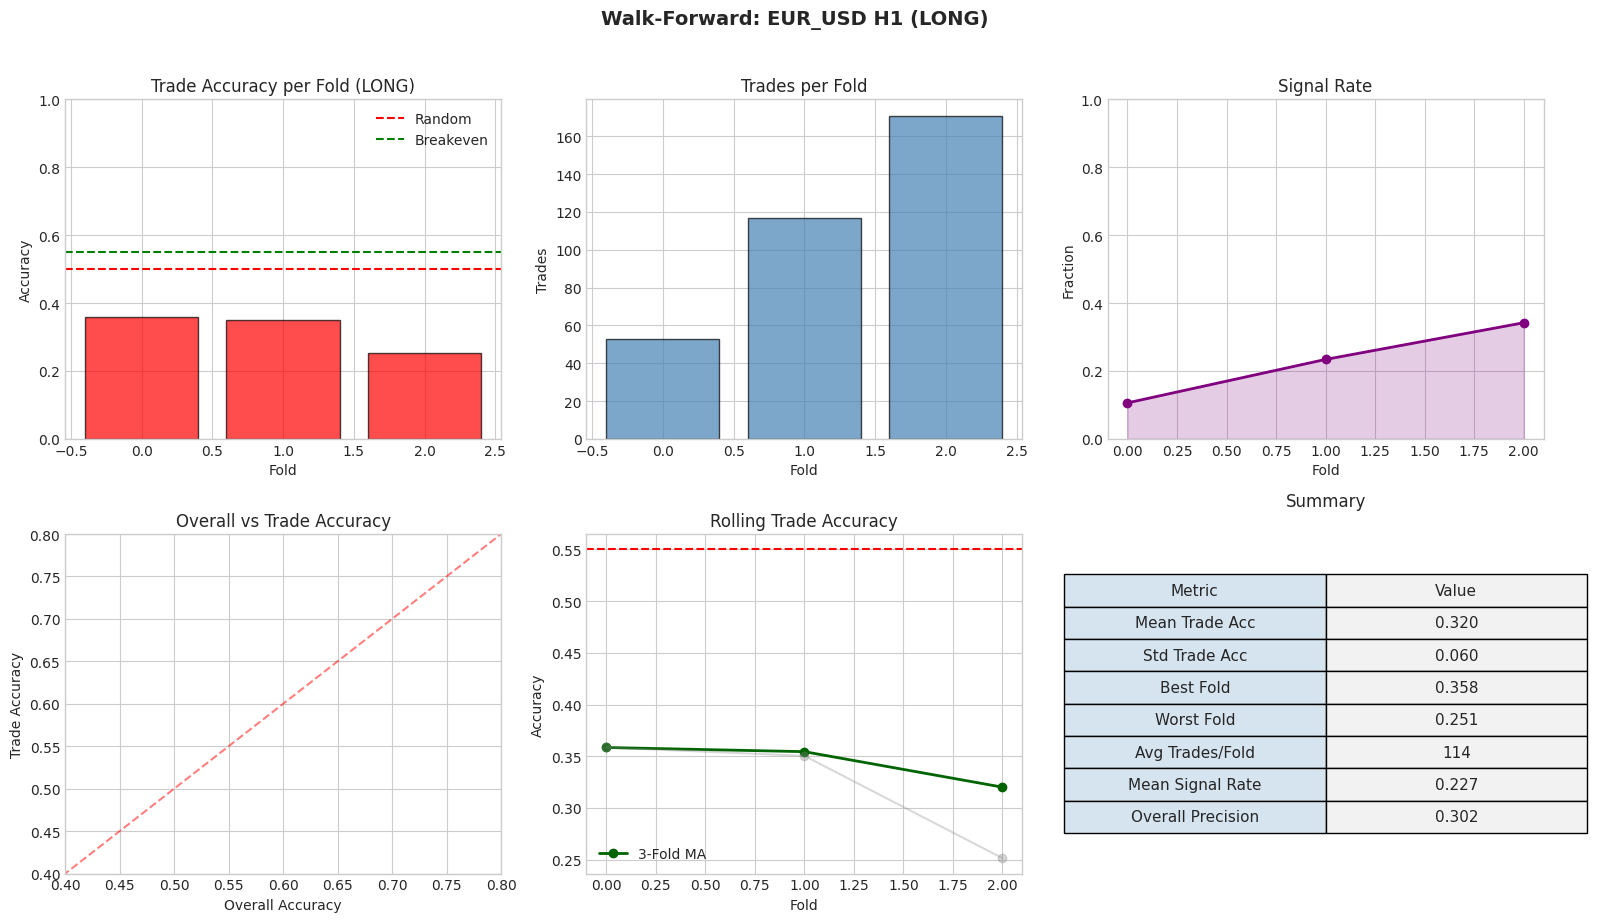


📊 Mean Trade Accuracy: 0.320
   Signal Rate: 22.7% of bars


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

ax = axes[0, 0]
colors = ['green' if x > 0.55 else 'orange' if x > 0.5 else 'red' for x in results_df['trade_accuracy']]
ax.bar(results_df['fold'], results_df['trade_accuracy'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0.5, color='red', linestyle='--', label='Random')
ax.axhline(y=0.55, color='green', linestyle='--', label='Breakeven')
ax.set_title(f'Trade Accuracy per Fold ({TRAIN_DIRECTION.upper()})')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_ylim(0, 1)

ax = axes[0, 1]
ax.bar(results_df['fold'], results_df['n_trades'], color='steelblue', alpha=0.7, edgecolor='black')
ax.set_title('Trades per Fold')
ax.set_xlabel('Fold')
ax.set_ylabel('Trades')

ax = axes[0, 2]
ax.plot(results_df['fold'], results_df['trade_rate'], marker='o', color='purple', linewidth=2)
ax.fill_between(results_df['fold'], results_df['trade_rate'], alpha=0.2, color='purple')
ax.set_title('Signal Rate')
ax.set_xlabel('Fold')
ax.set_ylabel('Fraction')
ax.set_ylim(0, 1)

ax = axes[1, 0]
ax.scatter(results_df['accuracy'], results_df['trade_accuracy'], s=100, alpha=0.6, edgecolors='black')
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5)
ax.set_xlabel('Overall Accuracy')
ax.set_ylabel('Trade Accuracy')
ax.set_title('Overall vs Trade Accuracy')
ax.set_xlim(0.4, 0.8)
ax.set_ylim(0.4, 0.8)

ax = axes[1, 1]
ax.plot(results_df['fold'], results_df['trade_accuracy'].rolling(3, min_periods=1).mean(),
        marker='o', color='darkgreen', linewidth=2, label='3-Fold MA')
ax.plot(results_df['fold'], results_df['trade_accuracy'], 'o-', alpha=0.3, color='gray')
ax.axhline(y=0.55, color='red', linestyle='--')
ax.set_title('Rolling Trade Accuracy')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.legend()

ax = axes[1, 2]
ax.axis('off')
summary = {
    'Metric': ['Mean Trade Acc', 'Std Trade Acc', 'Best Fold', 'Worst Fold', 'Avg Trades/Fold', 'Mean Signal Rate', 'Overall Precision'],
    'Value': [f"{results_df['trade_accuracy'].mean():.3f}", f"{results_df['trade_accuracy'].std():.3f}",
              f"{results_df['trade_accuracy'].max():.3f}", f"{results_df['trade_accuracy'].min():.3f}",
              f"{results_df['n_trades'].mean():.0f}", f"{results_df['trade_rate'].mean():.3f}",
              f"{results_df['precision'].mean():.3f}"]}
table = ax.table(cellText=[[summary['Metric'][i], summary['Value'][i]] for i in range(len(summary['Metric']))],
                 colLabels=['Metric', 'Value'], cellLoc='center', loc='center', colColours=['#4472C4']*2)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
for i in range(len(summary['Metric'])+1):
    table[(i, 0)].set_facecolor('#D6E4F0')
    table[(i, 1)].set_facecolor('#F2F2F2')
ax.set_title('Summary', pad=20)

plt.suptitle(f'Walk-Forward: {INSTRUMENT} {GRANULARITY} ({TRAIN_DIRECTION.upper()})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📊 Mean Trade Accuracy: {results_df['trade_accuracy'].mean():.3f}")
print(f"   Signal Rate: {results_df['trade_rate'].mean():.1%} of bars")

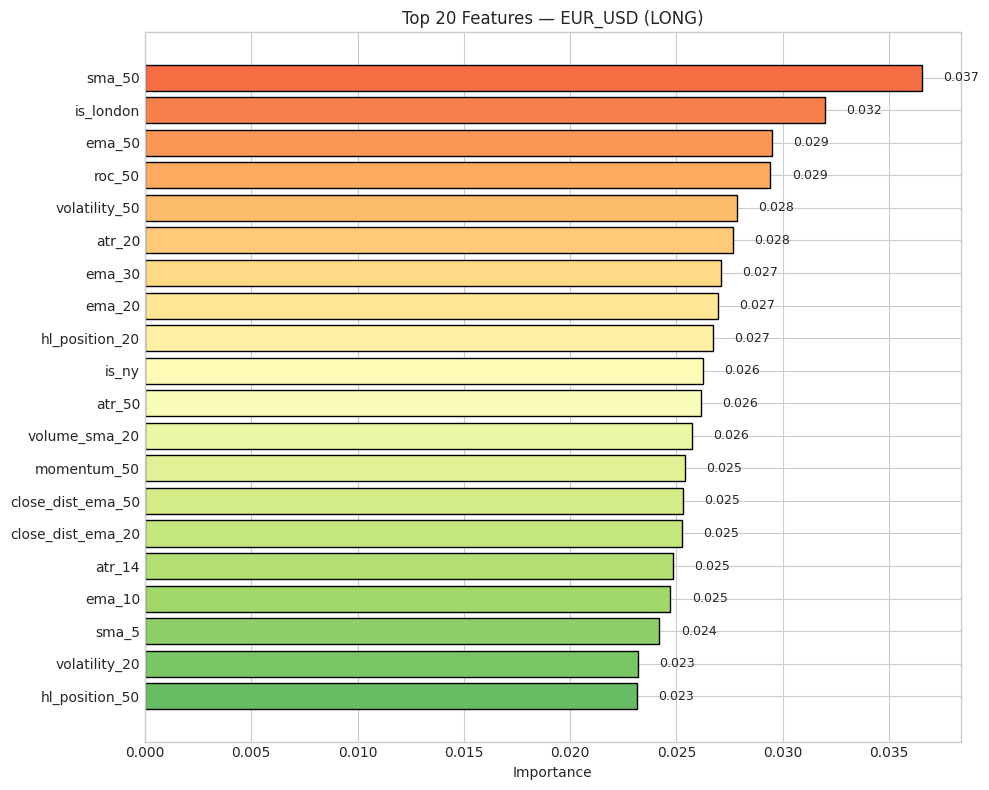

       feature  importance
        sma_50    0.036557
     is_london    0.032002
        ema_50    0.029496
        roc_50    0.029424
 volatility_50    0.027851
        atr_20    0.027649
        ema_30    0.027086
        ema_20    0.026947
hl_position_20    0.026703
         is_ny    0.026236


In [12]:
if wfx.model is None:
    print('❌ No model trained. Run walk-forward training first.')
else:
    imp_df = wfx.feature_importance().head(20)
    plt.figure(figsize=(10, 8))
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(imp_df)))
    bars = plt.barh(range(len(imp_df)), imp_df['importance'], color=colors, edgecolor='black')
    plt.yticks(range(len(imp_df)), imp_df['feature'])
    plt.xlabel('Importance')
    plt.title(f'Top 20 Features — {INSTRUMENT} ({TRAIN_DIRECTION.upper()})')
    plt.gca().invert_yaxis()
    for bar, val in zip(bars, imp_df['importance']):
        plt.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    print(imp_df.head(10).to_string(index=False))

## ⚡ Layer 6: Live Inference

**Dynamic direction:** If `DIRECTION='auto'`, the system detects current regime before generating the signal.

In [13]:
class LiveXGBFilter:
    def __init__(self, model_path, instrument, granularity='H1',
                 token=None, lookback_periods=None, atr_period=14,
                 direction='auto', regime_fast=20, regime_slow=50):
        self.model = joblib.load(model_path)
        self.fe = ForexFeatureEngineer(lookback_periods=lookback_periods or [5,10,20,50], atr_period=atr_period)
        self.instrument = instrument
        self.granularity = granularity
        self.token = token
        self.direction_mode = direction
        self.regime_fast = regime_fast
        self.regime_slow = regime_slow
        self.feature_cols = None
        if token and token != 'YOUR_ACCESS_TOKEN':
            self.client = oandapyV20.API(access_token=token, environment=OANDA_ENV)
        else:
            self.client = None
    
    def fetch_candles(self, count=200):
        if self.client is None: raise ValueError('OANDA client not initialized')
        params = {'count': count, 'granularity': self.granularity, 'price': 'M'}
        r = InstrumentsCandles(instrument=self.instrument, params=params)
        self.client.request(r)
        data = []
        for c in r.response['candles']:
            if not c['complete']: continue
            data.append({'time': pd.to_datetime(c['time']), 'open': float(c['mid']['o']),
                         'high': float(c['mid']['h']), 'low': float(c['mid']['l']),
                         'close': float(c['mid']['c']), 'volume': int(c['volume'])})
        return pd.DataFrame(data).set_index('time')
    
    def generate_signal(self, df=None, threshold=0.6):
        if df is None: df = self.fetch_candles(count=200)
        df = self.fe.compute_features(df)
        if self.feature_cols is None:
            self.feature_cols = self.fe.get_feature_columns(df)
        latest = df.iloc[-2]
        if latest[self.feature_cols].isna().any():
            return {'signal': 0, 'error': 'Insufficient data'}
        
        # Determine direction
        if self.direction_mode == 'auto':
            current_direction = detect_direction(df, fast=self.regime_fast, slow=self.regime_slow)
        else:
            current_direction = self.direction_mode
        
        X = latest[self.feature_cols].values.reshape(1, -1)
        proba = self.model.predict_proba(X)[:, 1][0]
        atr = latest.get(f'atr_{self.fe.atr_period}', df[f'atr_{self.fe.atr_period}'].iloc[-5:].mean())
        
        if current_direction == 'long':
            stop = float(latest['close'] - atr * RISK_MULTIPLE)
            target = float(latest['close'] + atr * REWARD_MULTIPLE)
        else:
            stop = float(latest['close'] + atr * RISK_MULTIPLE)
            target = float(latest['close'] - atr * REWARD_MULTIPLE)
        
        return {
            'signal': 1 if proba >= threshold else 0,
            'probability': float(proba), 'threshold': threshold,
            'direction': current_direction,
            'timestamp': latest.name.isoformat(), 'instrument': self.instrument,
            'close': float(latest['close']), 'atr_14': float(atr),
            'suggested_stop': stop,
            'suggested_target': target,
            'features': {k: float(v) for k, v in latest[self.feature_cols].items()}}

live_filter = LiveXGBFilter(f'best_xgb_model_{TRAIN_DIRECTION}.pkl', INSTRUMENT, GRANULARITY,
                            OANDA_TOKEN, LOOKBACKS, ATR_PERIOD, DIRECTION, REGIME_FAST_EMA, REGIME_SLOW_EMA)
signal = live_filter.generate_signal(df=df_clean.iloc[-200:], threshold=THRESHOLD)
print('═'*50)
print('🎯 LIVE SIGNAL')
print('═'*50)
print(f"Instrument:    {signal.get('instrument', 'N/A')}")
print(f"Direction:     {signal.get('direction', 'N/A').upper()}")
print(f"Timestamp:     {signal.get('timestamp', 'N/A')}")
print(f"Close:         {signal.get('close', 0):.5f}")
print(f"Signal:        {'🟢 TAKE TRADE' if signal['signal']==1 else '🔴 NO TRADE'}")
print(f"Probability:   {signal.get('probability', 0):.3f}")
print(f"ATR:           {signal.get('atr_14', 0):.5f}")
print(f"Suggested SL:  {signal.get('suggested_stop', 0):.5f}")
print(f"Suggested TP:  {signal.get('suggested_target', 0):.5f}")
print('═'*50)

══════════════════════════════════════════════════
🎯 LIVE SIGNAL
══════════════════════════════════════════════════
Instrument:    EUR_USD
Direction:     SHORT
Timestamp:     2026-07-28T10:00:00+00:00
Close:         1.13607
Signal:        🟢 TAKE TRADE
Probability:   0.878
ATR:           0.00077
Suggested SL:  1.13684
Suggested TP:  1.13452
══════════════════════════════════════════════════


## 📈 Layer 7: Backtest Simulation

**Dynamic regime:** The backtest detects direction per bar. Only takes trades aligned with the detected regime.

In [14]:
class XGBBacktester:
    def __init__(self, initial_capital=10000, risk_per_trade=0.01,
                 direction_mode='auto', regime_fast=20, regime_slow=50):
        self.initial_capital = initial_capital
        self.risk_per_trade = risk_per_trade
        self.direction_mode = direction_mode
        self.regime_fast = regime_fast
        self.regime_slow = regime_slow
    
    def run(self, df, model, feature_cols, threshold=0.6):
        equity = self.initial_capital
        trades = []
        for i in range(50, len(df) - MAX_BARS):
            row = df.iloc[i]
            if row[feature_cols].isna().any(): continue
            
            # Detect direction for this bar
            if self.direction_mode == 'auto':
                bar_direction = get_direction_for_bar(df, i, self.regime_fast, self.regime_slow)
            else:
                bar_direction = self.direction_mode
            
            # Skip if direction doesn't match model's training direction
            # (In production, you'd have separate long/short models)
            X = row[feature_cols].values.reshape(1, -1)
            proba = model.predict_proba(X)[:, 1][0]

            # if proba < threshold:
            #     trades.append({'bar': i, 'equity': equity, 'action': 'hold', 'direction': bar_direction})
            #     continue

            if proba < threshold:
                trades.append({
                    'bar': i, 
                    'timestamp': row.name,        # ← ADD THIS
                    'equity': equity, 
                    'action': 'hold', 
                    'direction': bar_direction
                })
                continue
            
            entry = row['close']
            atr = row.get(f'atr_{ATR_PERIOD}', df[f'atr_{ATR_PERIOD}'].iloc[max(0,i-5):i].mean())
            if bar_direction == 'long':
                sl = entry - atr * RISK_MULTIPLE
                tp = entry + atr * REWARD_MULTIPLE
            else:
                sl = entry + atr * RISK_MULTIPLE
                tp = entry - atr * REWARD_MULTIPLE
            future = df.iloc[i+1:i+1+MAX_BARS]
            if bar_direction == 'long':
                stop_hit = (future['low'] <= sl).any()
                target_hit = (future['high'] >= tp).any()
            else:
                stop_hit = (future['high'] >= sl).any()
                target_hit = (future['low'] <= tp).any()
            if target_hit and not stop_hit:
                result, pnl_pct = 'win', REWARD_MULTIPLE * self.risk_per_trade
            elif stop_hit and not target_hit:
                result, pnl_pct = 'loss', -RISK_MULTIPLE * self.risk_per_trade
            elif stop_hit and target_hit:
                result, pnl_pct = self._check_first(future, sl, tp, bar_direction)
            else:
                result, pnl_pct = 'timeout', 0
            equity = equity * (1 + pnl_pct)
            trades.append({'bar': i, 'timestamp': row.name, 'equity': equity, 'action': result,
                           'pnl_pct': pnl_pct * 100, 'probability': proba,
                           'entry': entry, 'sl': sl, 'tp': tp, 'direction': bar_direction})
        return pd.DataFrame(trades)
    
    def _check_first(self, future, sl, tp, direction):
        for _, bar in future.iterrows():
            if direction == 'long':
                if bar['low'] <= sl: return 'loss', -RISK_MULTIPLE * self.risk_per_trade
                if bar['high'] >= tp: return 'win', REWARD_MULTIPLE * self.risk_per_trade
            else:
                if bar['high'] >= sl: return 'loss', -RISK_MULTIPLE * self.risk_per_trade
                if bar['low'] <= tp: return 'win', REWARD_MULTIPLE * self.risk_per_trade
        return 'timeout', 0

bt = XGBBacktester(initial_capital=10000, risk_per_trade=0.01,
                   direction_mode=DIRECTION, regime_fast=REGIME_FAST_EMA, regime_slow=REGIME_SLOW_EMA)
trade_log = bt.run(df_clean, wfx.model, feature_cols, threshold=THRESHOLD)
actual_trades = trade_log[trade_log['action'] != 'hold']
print(f"📊 Backtest: {len(actual_trades)} trades | Win rate: {(actual_trades['action']=='win').mean():.1%}")
print(f"   Final Equity: ${trade_log['equity'].iloc[-1]:,.2f} | Return: {(trade_log['equity'].iloc[-1]/10000-1)*100:.2f}%")
print(f"   Max DD: {((trade_log['equity']/trade_log['equity'].cummax())-1).min()*100:.2f}%")
actual_trades.tail(10)

📊 Backtest: 1413 trades | Win rate: 39.8%
   Final Equity: $145,333.51 | Return: 1353.34%
   Max DD: -82.97%


,bar,timestamp,equity,action,direction,pnl_pct,probability,entry,sl,tp
4849,4899,2026-07-27 06:00:00+00:00,159092.239861,loss,long,-1.0,0.799100,1.14081,1.139827,1.142776
4850,4900,2026-07-27 07:00:00+00:00,157501.317462,loss,long,-1.0,0.887410,1.13964,1.138630,1.141660
4851,4901,2026-07-27 08:00:00+00:00,155926.304287,loss,long,-1.0,0.908839,1.14023,1.139187,1.142316
4852,4902,2026-07-27 09:00:00+00:00,154367.041245,loss,long,-1.0,0.908493,1.13964,1.138564,1.141791
4853,4903,2026-07-27 10:00:00+00:00,152823.370832,loss,long,-1.0,0.958045,1.13954,1.138456,1.141709
4854,4904,2026-07-27 11:00:00+00:00,151295.137124,loss,long,-1.0,0.969164,1.13865,1.137681,1.140587
4855,4905,2026-07-27 12:00:00+00:00,149782.185753,loss,long,-1.0,0.977077,1.13834,1.137359,1.140301
4856,4906,2026-07-27 13:00:00+00:00,148284.363895,loss,long,-1.0,0.960032,1.13743,1.136398,1.139494
4857,4907,2026-07-27 14:00:00+00:00,146801.520256,loss,short,-1.0,0.976589,1.13724,1.138196,1.135327
4858,4908,2026-07-27 15:00:00+00:00,145333.505054,loss,short,-1.0,0.976482,1.13752,1.138456,1.135647


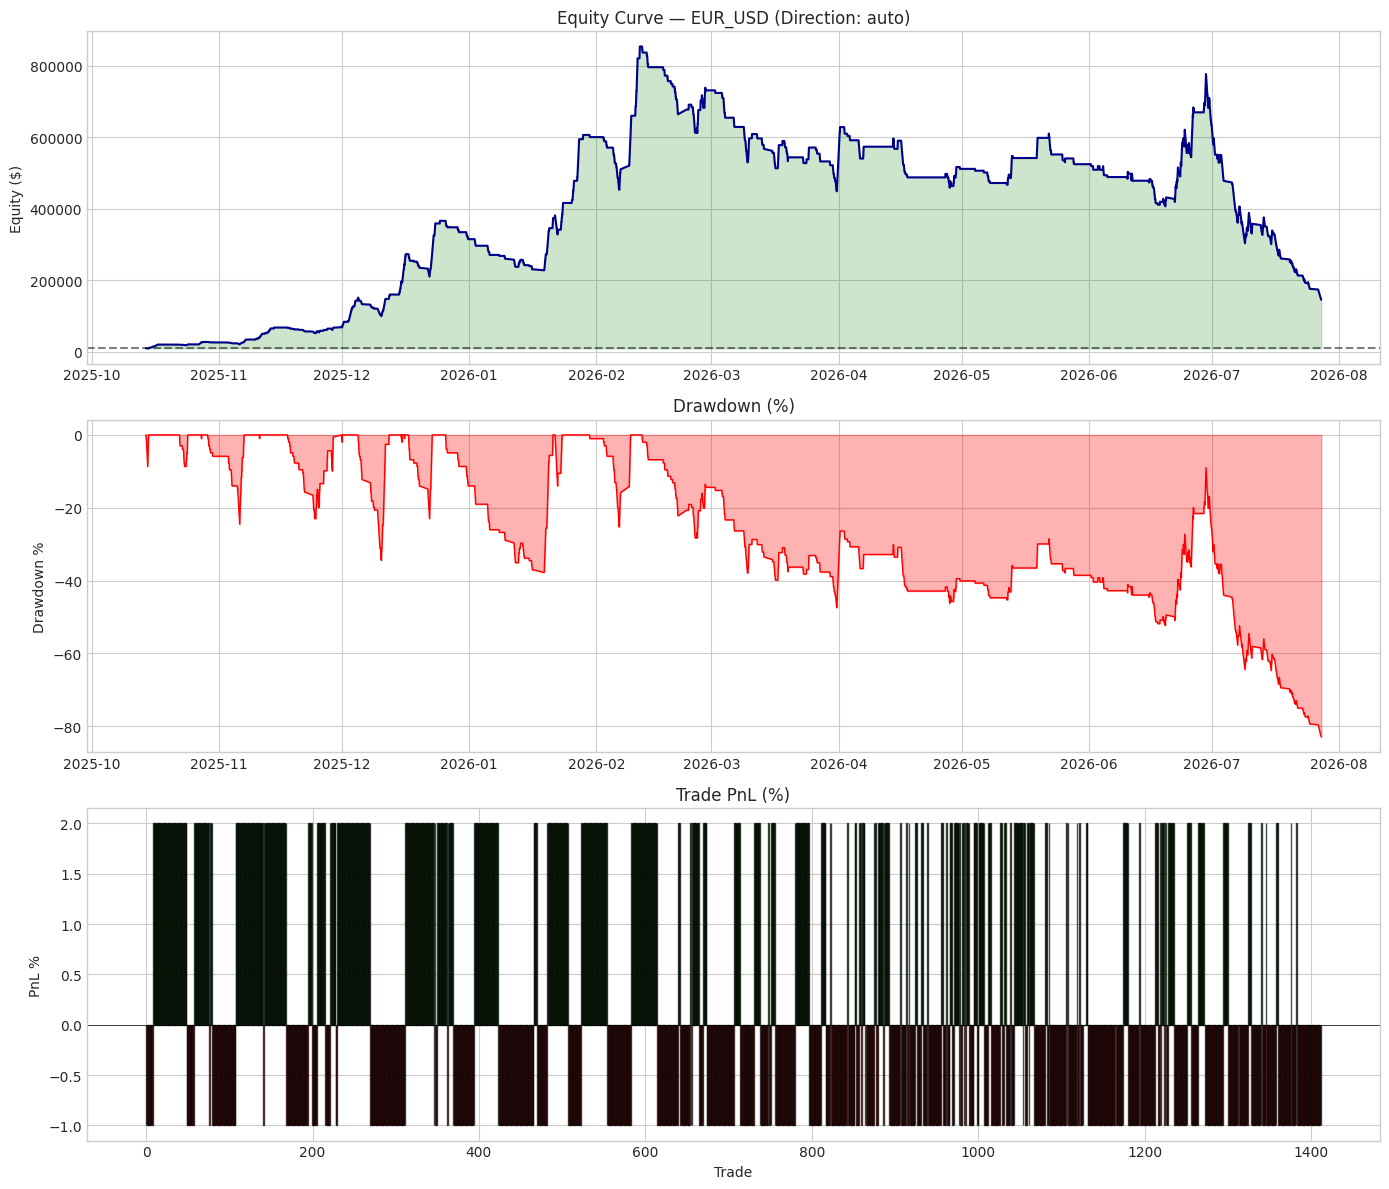

Avg Win: 2.00% | Avg Loss: -1.00%
Best: 2.00% | Worst: -1.00%
Profit Factor: 1.34 | Expectancy: 0.200%


In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
ax = axes[0]
ax.plot(trade_log['timestamp'], trade_log['equity'], linewidth=1.5, color='darkblue')
ax.fill_between(trade_log['timestamp'], trade_log['equity'], 10000,
                alpha=0.2, color='green' if trade_log['equity'].iloc[-1] > 10000 else 'red')
ax.axhline(y=10000, color='black', linestyle='--', alpha=0.5)
ax.set_title(f'Equity Curve — {INSTRUMENT} (Direction: {DIRECTION})')
ax.set_ylabel('Equity ($)')

ax = axes[1]
cummax = trade_log['equity'].cummax()
drawdown = (trade_log['equity'] - cummax) / cummax * 100
ax.fill_between(trade_log['timestamp'], drawdown, 0, alpha=0.3, color='red')
ax.plot(trade_log['timestamp'], drawdown, color='red', linewidth=1)
ax.set_title('Drawdown (%)')
ax.set_ylabel('Drawdown %')

ax = axes[2]
pnls = actual_trades['pnl_pct'].dropna()
colors = ['green' if x > 0 else 'red' for x in pnls]
ax.bar(range(len(pnls)), pnls, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Trade PnL (%)')
ax.set_xlabel('Trade')
ax.set_ylabel('PnL %')
plt.tight_layout()
plt.show()

wins = actual_trades[actual_trades['action'] == 'win']['pnl_pct']
losses = actual_trades[actual_trades['action'] == 'loss']['pnl_pct']
print(f"Avg Win: {wins.mean():.2f}% | Avg Loss: {losses.mean():.2f}%")
print(f"Best: {pnls.max():.2f}% | Worst: {pnls.min():.2f}%")
print(f"Profit Factor: {abs(wins.sum()/losses.sum()):.2f} | Expectancy: {pnls.mean():.3f}%")

## 🛡️ Layer 8: Risk Management

In [16]:
class RiskManager:
    def __init__(self, max_risk_per_trade=0.01, max_daily_drawdown=0.05,
                 max_open_trades=3, kill_switch=True):
        self.max_risk = max_risk_per_trade
        self.max_daily_dd = max_daily_drawdown
        self.max_open = max_open_trades
        self.kill_switch = kill_switch
        self.daily_pnl = 0
        self.open_trades = 0
        self.trade_history = []
        self.killed = False
    
    def can_trade(self, account_balance, current_dd):
        if self.killed: return False, 'KILL_SWITCH: Halted'
        if current_dd >= self.max_daily_dd:
            if self.kill_switch: self.killed = True
            return False, f'Daily DD limit: {current_dd:.2%}'
        if self.open_trades >= self.max_open:
            return False, f'Max open: {self.open_trades}'
        return True, 'OK'
    
    def position_size(self, balance, entry, stop_loss):
        risk_amount = balance * self.max_risk
        price_risk = abs(entry - stop_loss)
        if price_risk == 0: return 0
        return round(risk_amount / price_risk, 0)
    
    def record(self, entry, stop, target, units, result='open'):
        self.trade_history.append({'entry': entry, 'stop': stop, 'target': target,
                                   'units': units, 'result': result, 'timestamp': datetime.now()})
        self.open_trades += 1 if result == 'open' else -1
        self.open_trades = max(0, self.open_trades)
    
    def reset_daily(self):
        self.daily_pnl = 0; self.killed = False; print('🌅 Daily reset')

rm = RiskManager(max_risk_per_trade=0.01, max_daily_drawdown=0.05)
balance, entry, sl = 10000, 1.0850, 1.0820
can_trade, reason = rm.can_trade(balance, current_dd=0.02)
units = rm.position_size(balance, entry, sl)
print(f"Risk Check: {can_trade} ({reason})")
print(f"Position: {units:,.0f} units | Risk: ${balance*0.01:,.2f}")

Risk Check: True (OK)
Position: 33,333 units | Risk: $100.00


## 🔗 Layer 9: Complete Integration

**Dynamic direction** flows through the entire system via `config['direction']`.

In [17]:
class ForexTradingSystem:
    def __init__(self, config):
        self.config = config
        self.fe = ForexFeatureEngineer(
            lookback_periods=config.get('lookback_periods', [5,10,20,50]),
            atr_period=config.get('atr_period', 14))
        self.rm = RiskManager(max_risk_per_trade=config.get('max_risk', 0.01),
                              max_daily_drawdown=config.get('max_dd', 0.05))
        self.model = None
        self.feature_cols = None
        token = config.get('oanda_token')
        if token and token != 'YOUR_ACCESS_TOKEN':
            self.client = oandapyV20.API(access_token=token, environment=config.get('env', 'practice'))
        else:
            self.client = None
    
    def train(self, df, direction=None):
        if direction is None:
            direction = self.config.get('direction', 'long')
        if direction == 'auto':
            df_temp = self.fe.compute_features(df.copy())
            direction = detect_direction(df_temp,
                fast=self.config.get('regime_fast', 20),
                slow=self.config.get('regime_slow', 50))
            print(f"🌊 Auto-detected training direction: {direction.upper()}")
        df = self.fe.compute_features(df)
        lg = LabelGenerator(risk_multiple=self.config.get('risk_mult', 1.0),
                            reward_multiple=self.config.get('reward_mult', 2.0),
                            max_bars=self.config.get('max_bars', 20),
                            atr_period=self.config.get('atr_period', 14))
        df['target'] = lg.generate_labels(df, direction=direction)
        self.feature_cols = self.fe.get_feature_columns(df)
        df_clean = df.dropna(subset=self.feature_cols + ['target'])
        df_clean = df_clean[df_clean['target'].isin([0, 1])]
        wfx = WalkForwardXGB(train_window=self.config.get('train_window', 3000),
                             test_window=self.config.get('test_window', 500),
                             step_size=self.config.get('step_size', 500),
                             threshold=self.config.get('threshold', 0.6))
        results = wfx.train(df_clean, self.feature_cols)
        self.model = wfx.model
        self.train_direction = direction
        return results, wfx
    
    def get_signal(self, df=None, threshold=None, direction=None):
        if threshold is None: threshold = self.config.get('threshold', 0.6)
        if df is None and self.client:
            params = {'count': 200, 'granularity': self.config.get('granularity', 'H1'), 'price': 'M'}
            r = InstrumentsCandles(instrument=self.config.get('instrument', 'EUR_USD'), params=params)
            self.client.request(r)
            data = []
            for c in r.response['candles']:
                if not c['complete']: continue
                data.append({'time': pd.to_datetime(c['time']), 'open': float(c['mid']['o']),
                             'high': float(c['mid']['h']), 'low': float(c['mid']['l']),
                             'close': float(c['mid']['c']), 'volume': int(c['volume'])})
            df = pd.DataFrame(data).set_index('time')
        df = self.fe.compute_features(df)
        latest = df.iloc[-2]
        if latest[self.feature_cols].isna().any():
            return {'signal': 0, 'error': 'Insufficient data'}
        
        # Determine direction
        if direction is None:
            direction = self.config.get('direction', 'long')
        if direction == 'auto':
            direction = detect_direction(df,
                fast=self.config.get('regime_fast', 20),
                slow=self.config.get('regime_slow', 50))
        
        X = latest[self.feature_cols].values.reshape(1, -1)
        proba = self.model.predict_proba(X)[:, 1][0]
        atr = latest.get(f'atr_{self.config.get("atr_period", 14)}',
                         df[f'atr_{self.config.get("atr_period", 14)}'].iloc[-5:].mean())
        if direction == 'long':
            stop = float(latest['close'] - atr * self.config.get('risk_mult', 1.0))
            target = float(latest['close'] + atr * self.config.get('reward_mult', 2.0))
        else:
            stop = float(latest['close'] + atr * self.config.get('risk_mult', 1.0))
            target = float(latest['close'] - atr * self.config.get('reward_mult', 2.0))
        return {
            'signal': 1 if proba >= threshold else 0,
            'probability': float(proba), 'timestamp': latest.name.isoformat(),
            'direction': direction,
            'close': float(latest['close']), 'atr': float(atr),
            'stop': stop, 'target': target}
    
    def execute(self, signal, balance):
        can_trade, reason = self.rm.can_trade(balance, current_dd=0.0)
        if not can_trade:
            return {'executed': False, 'reason': reason}
        if signal['signal'] != 1:
            return {'executed': False, 'reason': 'No signal'}
        units = self.rm.position_size(balance, signal['close'], signal['stop'])
        self.rm.record(signal['close'], signal['stop'], signal['target'], units, 'open')
        return {'executed': True, 'units': units, 'entry': signal['close'],
                'stop': signal['stop'], 'target': signal['target'],
                'probability': signal['probability'], 'direction': signal['direction']}

config = {
    'instrument': INSTRUMENT,
    'granularity': GRANULARITY,
    'direction': DIRECTION,           # 'auto', 'long', or 'short'
    'regime_fast': REGIME_FAST_EMA,   # 20
    'regime_slow': REGIME_SLOW_EMA,   # 50
    'oanda_token': OANDA_TOKEN,
    'env': OANDA_ENV,
    'lookback_periods': LOOKBACKS,
    'threshold': 0.6,
    'atr_period': 14,
    'risk_mult': 1.0,
    'reward_mult': 2.0,
    'max_bars': 20,
    'train_window': 3000,
    'test_window': 500,
    'step_size': 500,
    'max_risk': 0.01,
    'max_dd': 0.05
}

system = ForexTradingSystem(config)
print('✅ ForexTradingSystem initialized')
print(f"   Direction mode: {config['direction']}")
print('Use: system.train(df) → system.get_signal() → system.execute()')

✅ ForexTradingSystem initialized
   Direction mode: auto
Use: system.train(df) → system.get_signal() → system.execute()


## 🚀 Next Steps

1. **Production dual-model setup:** Train separate long and short models. Save as `best_xgb_model_long.pkl` and `best_xgb_model_short.pkl`. At runtime, detect regime and load the appropriate model.
2. **Paper trade** for 2-4 weeks before live deployment
3. **Monitor regime accuracy:** Track how often the EMA cross correctly predicts the dominant direction
4. **Add ADX filter:** Only trade when trend strength > 25 (avoid chop)
5. **Add logging:** Persist all predictions, regime, trades, and P&L to your database

## ⚠️ Risk Warning

- Past performance ≠ future results
- Forex carries significant risk of loss
- Never trade with money you cannot afford to lose
- Start with 0.01 lots (micro) even after paper trading success